In [2]:
import matplotlib.pyplot as plt
import csv

In [42]:
def get_k_vs_accuracy(model_size: int, exp_name:str, pp_samples: int):
    """Returns the k vs accuracy for a given model size, experiment name and number of pp samples."""
    x = []
    y = []
    for i in range(1, 6):
        yi = []
        x = []
        file_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-{model_size}B-Instruct/0.7/accuracy_fast_{i}.csv"
        with open(file_path, mode='r', newline='') as csv_file:
            csv_reader = csv.reader(csv_file, delimiter=',')
            data_list = []
            for row in csv_reader:
                data_list.append(row)
        data_list = data_list[2 if exp_name == "cruxeval_new" else 1:]
        pp_data_list = list(filter(lambda x: int(x[1]) == pp_samples + (1 if exp_name == "cruxeval_new" else 0), data_list))
        x += [int(i[0]) for i in pp_data_list]
        yi += [float(i[2]) for i in pp_data_list]
        y.append(yi)
    
    # compute mean of y
    y_mean = [sum(i)/len(i) for i in zip(*y)]
    return x, y_mean

# Usage
x, y = get_k_vs_accuracy(0.5, "gsm8k", 0)


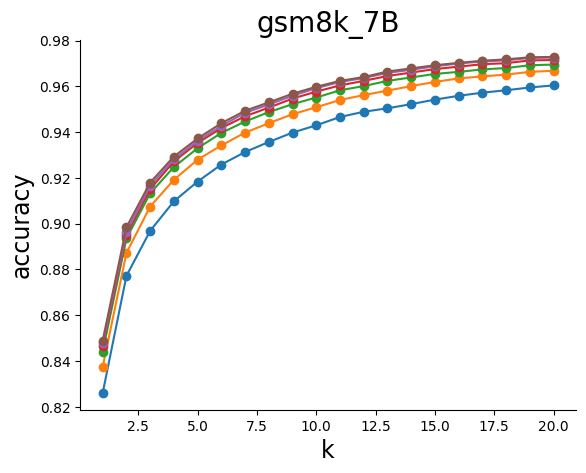

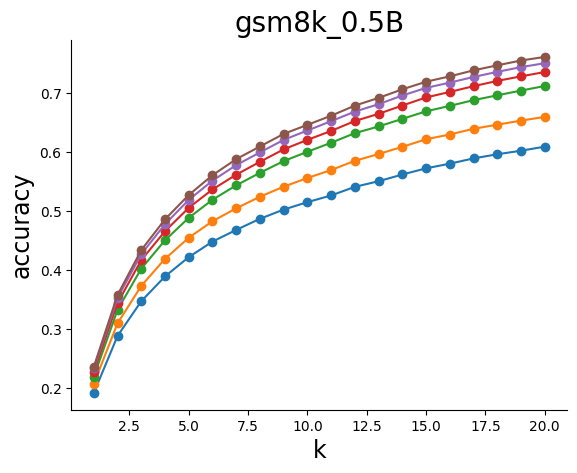

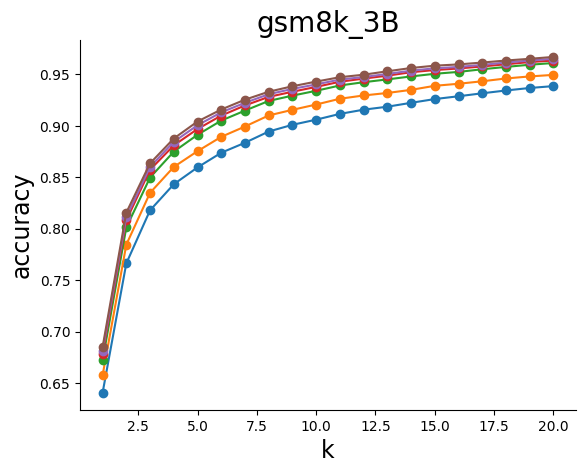

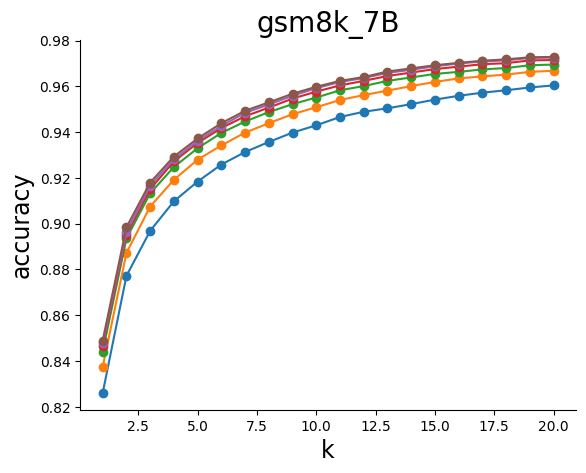

In [18]:
def plot_k_vs_accuracy(model_size: int, exp_name:str):
    fig, ax = plt.subplots()
    
    x1, y1 = get_k_vs_accuracy(model_size, exp_name, 0)
    ax.plot(x1, y1, marker='o', label='LLM only')
    x2, y2 = get_k_vs_accuracy(model_size, exp_name, 1)
    ax.plot(x2, y2, marker='o', label='LLM + 1 PP')
    x3, y3 = get_k_vs_accuracy(model_size, exp_name, 5)
    ax.plot(x3, y3, marker='o', label='LLM + 5 PP')
    x4, y4 = get_k_vs_accuracy(model_size, exp_name, 10)
    ax.plot(x4, y4, marker='o', label='LLM + 10 PP')
    x5, y5 = get_k_vs_accuracy(model_size, exp_name, 15)
    ax.plot(x5, y5, marker='o', label='LLM + 15 PP')
    x6, y6 = get_k_vs_accuracy(model_size, exp_name, 20)
    ax.plot(x6, y6, marker='o', label='LLM + 20 PP')

    # Save data in a csv file
    with open(f"/space/poorvagarg/genPPS/{exp_name}/plots/k_vs_accuracy_{model_size}B.csv", mode='w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file, delimiter=',')
        csv_writer.writerow(['k', 'LLM only', 'LLM + 1 PP', 'LLM + 5 PP', 'LLM + 10 PP', 'LLM + 15 PP', 'LLM + 20 PP'])
        for i in range(len(x1)):
            csv_writer.writerow([x1[i], y1[i], y2[i], y3[i], y4[i], y5[i], y6[i]])

    ax.set_xlabel("k", fontsize=17)
    ax.set_ylabel("accuracy", fontsize=17)
    # ax.legend(fontsize=17)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_xlim(0, 40)
    ax.set_title(f"{exp_name}_{model_size}B", fontsize=20)
    fig.savefig(f"/space/poorvagarg/genPPS/{exp_name}/plots/k_vs_accuracy_{model_size}B.pdf", dpi=300)
    return fig

plot_k_vs_accuracy(0.5, "gsm8k")
plot_k_vs_accuracy(3, "gsm8k")
plot_k_vs_accuracy(7, "gsm8k")

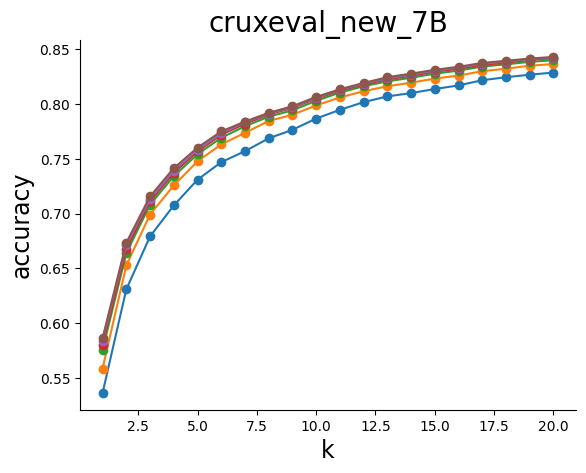

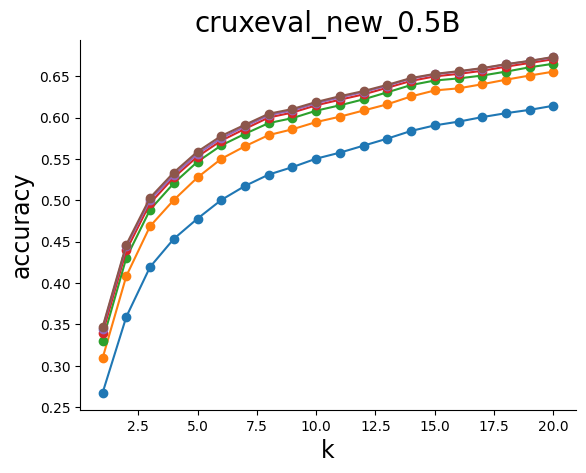

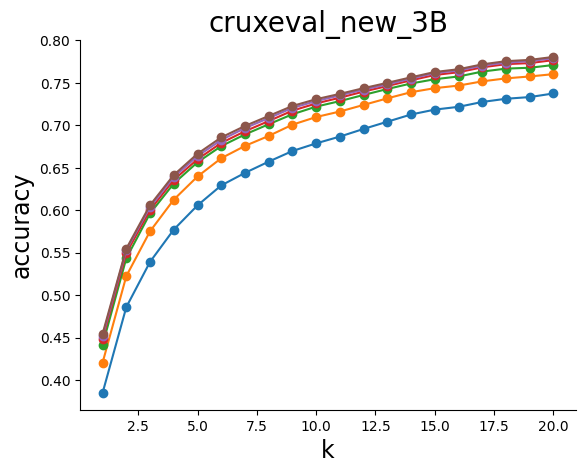

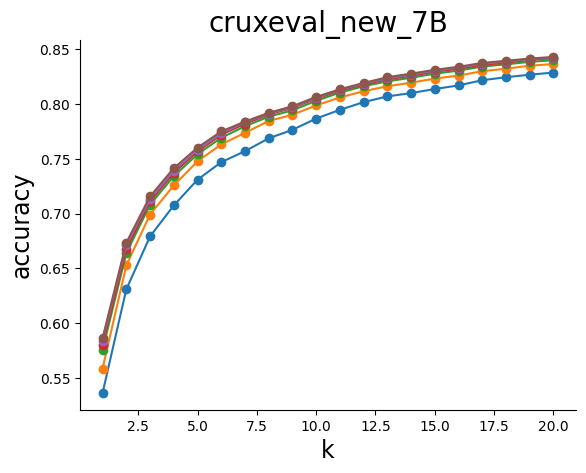

In [44]:
plot_k_vs_accuracy(0.5, "cruxeval_new")
plot_k_vs_accuracy(3, "cruxeval_new")
plot_k_vs_accuracy(7, "cruxeval_new")

In [55]:
def get_k_vs_time_data(exp_name:str, model_size: int):
    """Returns the k vs time for a given experiment name and number of pp samples."""
    x = []
    y0, y1, y5, y10, y15, y20 = [], [], [], [], [], []
    for i in range(1, 20):
        x.append(i)
        file_name = f"time_{i}_fast_.txt" if exp_name == "cruxeval_new" else f"time_{i}_simple_{i}.txt"
        file_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-0.5B-Instruct/0.7/{file_name}"
        with open(file_path, 'r') as f:
            lines = f.readlines()
        y0.append(float(lines[4].split(":")[1].strip()))
        y1.append(float(lines[12].split(":")[1].strip()))
        y5.append(float(lines[13 if exp_name == "cruxeval_new" else 14].split(":")[1].strip()))
        y10.append(float(lines[14 if exp_name == "cruxeval_new" else 16].split(":")[1].strip()))
        y15.append(float(lines[15 if exp_name == "cruxeval_new" else 18].split(":")[1].strip()))
        y20.append(float(lines[16 if exp_name == "cruxeval_new" else 20].split(":")[1].strip()))

    # Save data in a csv file
    with open(f"/space/poorvagarg/genPPS/{exp_name}/plots/k_vs_time_{model_size}B.csv", mode='w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file, delimiter=',')
        csv_writer.writerow(['k', 'LLM only', 'LLM + 1 PP', 'LLM + 5 PP', 'LLM + 10 PP', 'LLM + 15 PP', 'LLM + 20 PP'])
        for i in range(len(x)):
            csv_writer.writerow([x[i], y0[i], y1[i], y5[i], y10[i], y15[i], y20[i]])
    
    return x, y0, y1, y5, y10, y15, y20

In [52]:
def plot_k_vs_time(exp_name:str, model_size: int):
    fig, ax = plt.subplots()
    x, y0, y1, y5, y10, y15, y20 = get_k_vs_time_data(exp_name, model_size)
    ax.plot(x, y0, marker='o', label='LLM only')
    ax.plot(x, y1, marker='o', label='LLM + 1 PP')
    ax.plot(x, y5, marker='o', label='LLM + 5 PP')
    ax.plot(x, y10, marker='o', label='LLM + 10 PP')
    ax.plot(x, y15, marker='o', label='LLM + 15 PP')
    ax.plot(x, y20, marker='o', label='LLM + 20 PP')
    ax.set_xlabel("k", fontsize=17)
    ax.set_ylabel("time (s)", fontsize=17)
    # ax.legend(fontsize=17)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_xlim(0, 40)
    ax.set_title(f"{exp_name}_{model_size}B", fontsize=20)
    fig.savefig(f"/space/poorvagarg/genPPS/{exp_name}/plots/k_vs_time_{model_size}B.pdf", dpi=300)
    return fig

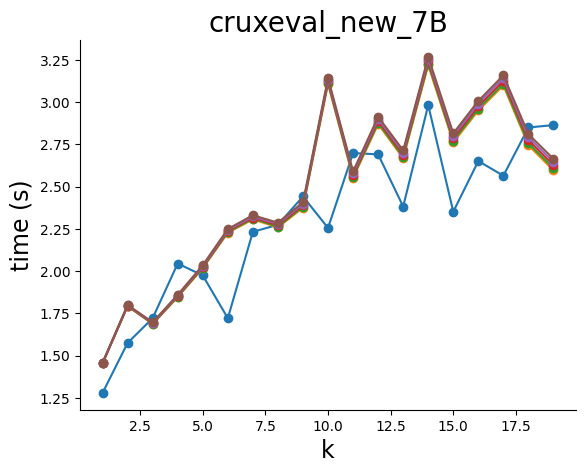

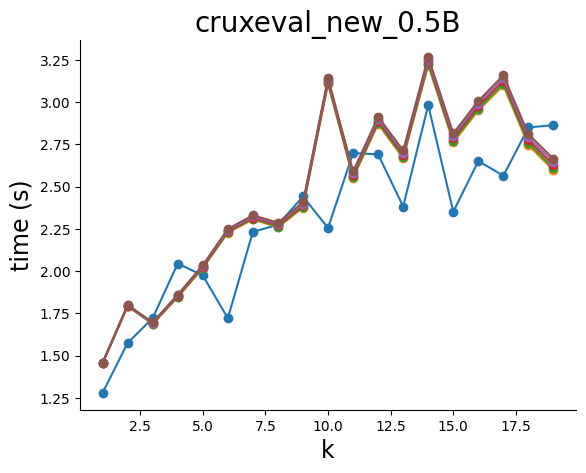

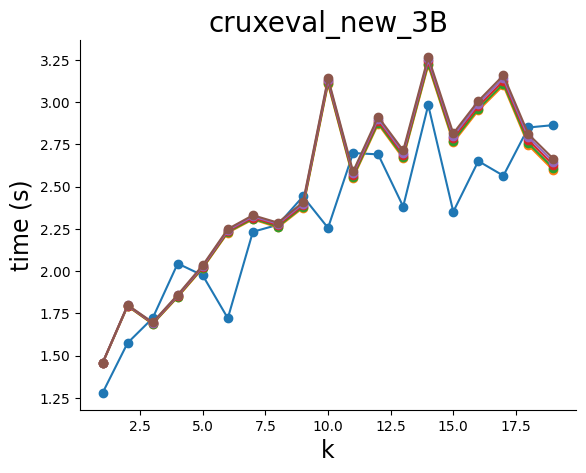

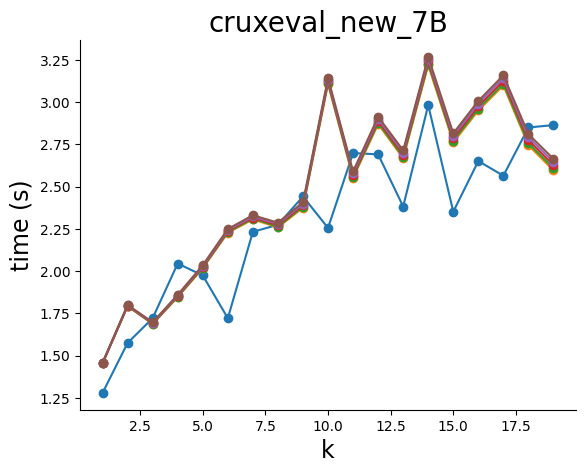

In [53]:
plot_k_vs_time("cruxeval_new", 0.5)
plot_k_vs_time("cruxeval_new", 3)
plot_k_vs_time("cruxeval_new", 7)

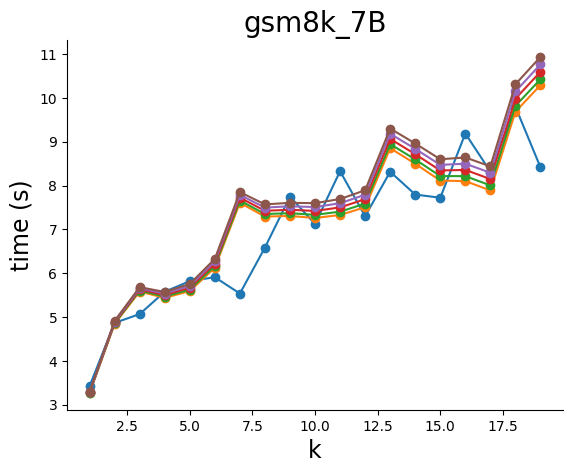

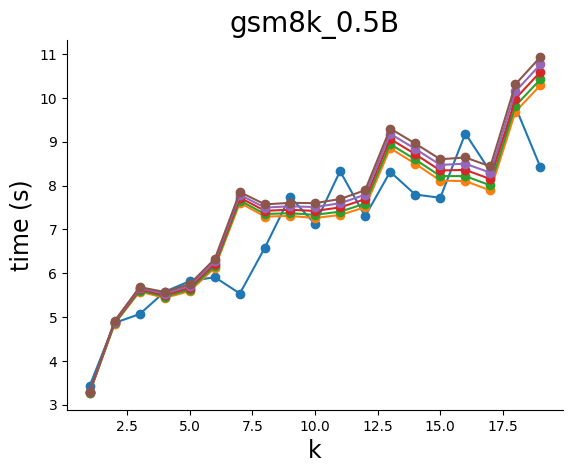

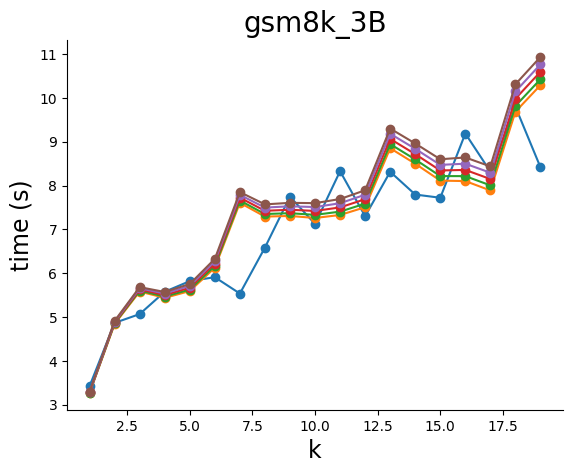

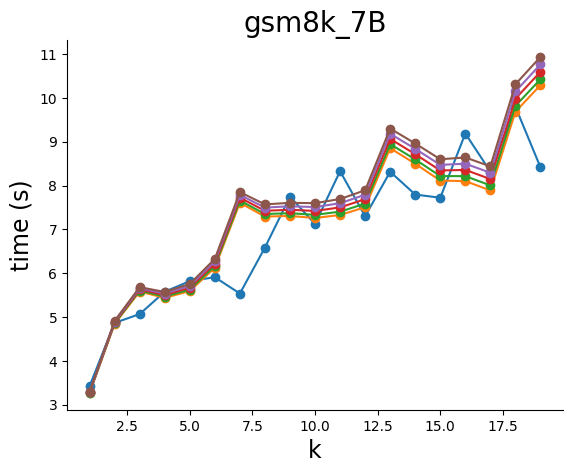

In [56]:
plot_k_vs_time("gsm8k", 0.5)
plot_k_vs_time("gsm8k", 3)
plot_k_vs_time("gsm8k", 7)

In [ ]:
def get_k_vs_accuracy(model_size: int, exp_name:str, pp_samples: int):
    x = []
    y = []
    for i in range(1, 6):
        yi = []
        file_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-{model_size}B-Instruct/0.7/accuracy_fast_{i}.csv"
        with open(file_path, mode='r', newline='') as csv_file:
            csv_reader = csv.reader(csv_file, delimiter=',')
            data_list = []
            for row in csv_reader:
                data_list.append(row)
        pp_data_list = list(filter(lambda x: int(x[1]) == pp_samples, data_list[1:]))
        x += [int(i[0]) for i in pp_data_list]
        yi += [float(i[2]) for i in pp_data_list]
        y.append(yi)
    
    # compute mean of y
    y_mean = [sum(i)/len(i) for i in zip(*y)]
    return x, y_mean

    
    data_list = []

    with open(file_path, mode='r', newline='') as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        for row in csv_reader:
            data_list.append(row)

    data_list = data_list[1 if exp_name == "gsm8k" else 2:]

    k_vs_accuracy = {}
    for row in data_list:
        k = int(row[0])*(int(row[1])+(0 if exp_name == "gsm8k" else 1))
        accuracy = float(row[2])
        k_vs_accuracy[k] = accuracy

    return k_vs_accuracy

def plotkvsaccuracy(model_size: int, exp_name:str):
    file_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-{model_size}B-Instruct/0.7/accuracy.csv"
    data_list = []

    with open(file_path, mode='r', newline='') as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        for row in csv_reader:
            data_list.append(row)

    data_list = data_list[1 if exp_name == "gsm8k" else 2:]

    def plot_pp_data(ax, num_samples):
        pp_data_list = list(filter(lambda x: int(x[1]) == num_samples + (0 if exp_name == "gsm8k" else 1), data_list))
        # num_samples = 0
        x = [int(i[0])*(num_samples+1) for i in pp_data_list]
        y = [float(i[2]) for i in pp_data_list]
        ax.plot(x, y)

    fig, ax = plt.subplots()
    plot_pp_data(ax, 0)
    plot_pp_data(ax, 1)
    plot_pp_data(ax, 5)
    plot_pp_data(ax, 10)
    plot_pp_data(ax, 20)
    ax.set_xlabel("k", fontsize=17)
    ax.set_ylabel("pass@k", fontsize=17)
    ax.legend(["k LLM", "k LLM + 1 PP", "k LLM + 5 PP", "k LLM + 10 PP", "k LLM + 20 PP"], fontsize=17)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, 40)
    ax.set_title(f"{model_size}B", fontsize=20)
    fig.savefig(f"/space/poorvagarg/genPPS/{exp_name}/plots/pass@k_{model_size}B.pdf", dpi=300)
    return fig

plotkvsaccuracy(0.5, "gsm8k")
plotkvsaccuracy(3, "gsm8k")
plotkvsaccuracy(7, "gsm8k")


In [ ]:
def plotkvstime(model_size: int, exp_name: str):
    folder_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-{model_size}B-Instruct/0.7"
    data_list = []

    def plot_pp_data(ax, pp_samples):
        x = []
        y = []
        speedup = []
        for i in range(1, 15):
            pp_samples_file = 1 if pp_samples == 0 else pp_samples
            fast_suffix = "_fast" if exp_name == "gsm8k" else ""
            file_path = f"{folder_path}/time_{i}_{pp_samples_file}{fast_suffix}.txt"
            # print(file_path)
            # print(fast_suffix)
            with open(file_path, mode='r') as f:
                lines = f.readlines()
                x.append(i)
                line_idx = 3 if pp_samples == 0 else 7
                time = float(lines[line_idx].split(":")[1])
                baseline_time = float(lines[3].split(":")[1])
                speedup.append(time / baseline_time)
                y.append(time)
        print(min(speedup), max(speedup))
        ax.plot(x, y)

        

    fig, ax = plt.subplots()
    plot_pp_data(ax, 0)
    plot_pp_data(ax, 1)
    plot_pp_data(ax, 5)
    plot_pp_data(ax, 10)
    plot_pp_data(ax, 15)
    plot_pp_data(ax, 20)
    ax.set_xlabel("k", fontsize=17)
    ax.set_ylabel("time (in s)", fontsize=17)
    ax.legend(["k LLM", "k LLM + 1 PP", "k LLM + 5 PP", "k LLM + 10 PP", "k LLM + 15 PP", "k LLM + 20 PP"], fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(f"{model_size}B", fontsize=17)
    fig.savefig(f"/space/poorvagarg/genPPS/{exp_name}/plots/time_{model_size}B.pdf", dpi=300)
    return fig

plotkvstime(0.5, "gsm8k")
plotkvstime(3, "gsm8k")
plotkvstime(7, "gsm8k")

In [ ]:
plotkvsaccuracy(0.5, "cruxeval_new")
plotkvsaccuracy(3, "cruxeval_new")
plotkvsaccuracy(7, "cruxeval_new")

In [ ]:
plotkvstime(0.5, "cruxeval_new")
plotkvstime(3, "cruxeval_new")
plotkvstime(7, "cruxeval_new")

20 20
20 20
20 20
20 20
20 20
20 20
20 20
20 20
20 20
20 20


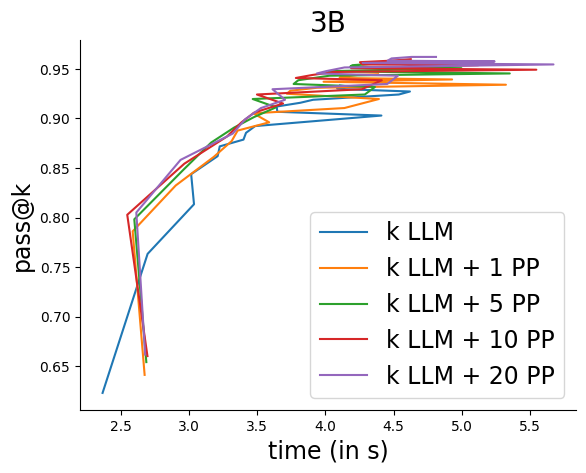

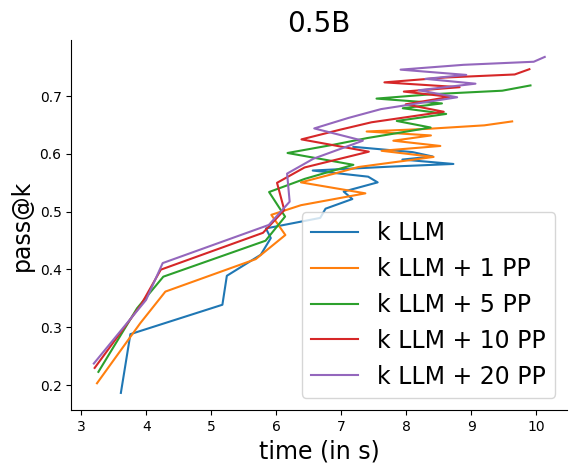

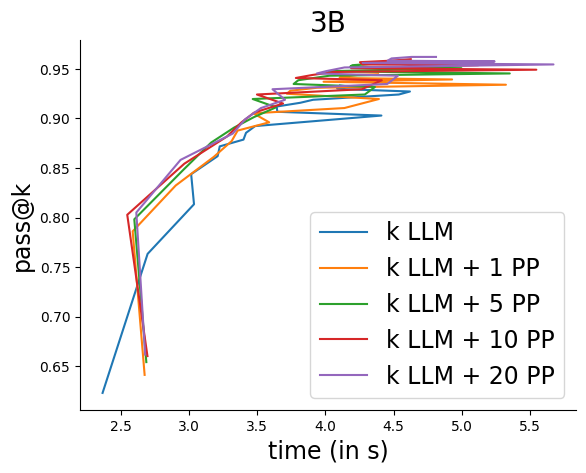

In [12]:
def plottimevsaccuracy(model_size: int, exp_name: str):
    folder_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-{model_size}B-Instruct/0.7"

    def get_time_data(ax, pp_samples):
        x = []
        y = []
        speedup = []
        for i in range(1, 21):
            pp_samples_file = 1 if pp_samples == 0 else pp_samples
            fast_suffix = "_fast" if exp_name == "gsm8k" else ""
            file_path = f"{folder_path}/time_{i}_{pp_samples_file}{fast_suffix}.txt"
            # print(file_path)
            # print(fast_suffix)
            with open(file_path, mode='r') as f:
                lines = f.readlines()
                x.append(i)
                line_idx = 3 if pp_samples == 0 else 7
                time = float(lines[line_idx].split(":")[1])
                baseline_time = float(lines[3].split(":")[1])
                speedup.append(time / baseline_time)
                y.append(time)
        # print(min(speedup), max(speedup))
        return x, y
    
    file_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-{model_size}B-Instruct/0.7/accuracy.csv"
    data_list = []

    with open(file_path, mode='r', newline='') as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        for row in csv_reader:
            data_list.append(row)

    data_list = data_list[1 if exp_name == "gsm8k" else 2:]

    def get_accuracy_data(ax, num_samples):
        pp_data_list = list(filter(lambda x: int(x[1]) == num_samples + (0 if exp_name == "gsm8k" else 1), data_list))
        # num_samples = 0
        x = [int(i[0])*(num_samples+1) for i in pp_data_list]
        y = [float(i[2]) for i in pp_data_list]
        return x, y

    def plot_data(ax, num_samples):
        time_x, time_y = get_time_data(ax, num_samples)
        acc_x, acc_y = get_accuracy_data(ax, num_samples)
        print(len(time_y), len(acc_y))
        ax.plot(time_y, acc_y)

    fig, ax = plt.subplots()

    plot_data(ax, 0)
    plot_data(ax, 1)
    plot_data(ax, 5)
    plot_data(ax, 10)
    plot_data(ax, 20)
    ax.set_xlabel("time (in s)", fontsize=17)
    ax.set_ylabel("pass@k", fontsize=17)
    ax.legend(["k LLM", "k LLM + 1 PP", "k LLM + 5 PP", "k LLM + 10 PP", "k LLM + 20 PP"], fontsize=17)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_xlim(0, 40)
    ax.set_title(f"{model_size}B", fontsize=20)
    fig.savefig(f"/space/poorvagarg/genPPS/{exp_name}/plots/pass@k_time_{model_size}B.pdf", dpi=300)
    return fig
    
    
plottimevsaccuracy(0.5, "gsm8k")
plottimevsaccuracy(3, "gsm8k")
# plottimevsaccuracy(7, "gsm8k")